# 2 — The method and its validation

The route from dynamics to conformal data runs through the Loschmidt echo. After a Wick
rotation the echo becomes the partition function of a CFT on a strip, and transverse
contraction evaluates it: the space–time tensor network is contracted along the *spatial*
direction, so the whole evolution reduces to the leading eigenvalues of a single spatial
transfer matrix acting on temporal MPS.

Three ingredients have to be right before any number can be trusted:

1. the evolution operator $U(\delta t)$ as an MPO of genuine second order;
2. the **transfer-matrix column** extracted from it — where the NNN coupling hides a trap;
3. the eigensolver — a block power method, because the transfer matrix is non-normal.

This notebook tests each one, ending with the benchmark that gates everything: at $p = 0$ the
model is the integrable Ising chain and every conformal answer is known exactly.

Production settings throughout the thesis: $\delta t = 0.1$, cooling regulator $n_\beta = 4$
($\beta_0 = 0.2$), VD2 kernel, $\chi = 64$, block size $k = 4$ ($k = 8$ for the towers), and
`column = :bulk5`.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The time-evolution MPO: which kernel is actually unitary?

$U(\delta t)$ is built directly as a uniform MPO from a finite-state-machine encoding of $H$.
Three kernels are implemented: the classic $W^{\mathrm{I}}$ and $W^{\mathrm{II}}$
constructions, and the VD2 construction of Van Damme et al. The simplest possible test says
almost everything: a unitary operator must preserve the norm, so apply $U(\delta t)$ layer by
layer to $|X+\rangle^{\otimes N}$ and just *watch* $\lVert\psi\rVert$. (This runs live —
eight layers at $N = 100$, a few seconds per kernel.)

In [2]:
# apply `layers` copies of U(dt) to |X+>^N and report the norm drift per kernel
function test_unitarity(N, lambda, p, dt, layers; mpo_alg="VD2", cutoff=1e-12, maxdim=256)
    sites = siteinds("S=1/2", N)
    U     = expH_alcaraz(sites, lambda, p; dt=dt, mpo_alg=mpo_alg)
    psi   = complex(MPS(sites, "X+"))
    println("--- $mpo_alg ---")
    for L in 1:layers
        psi = apply(U, psi; cutoff=cutoff, maxdim=maxdim)
        @printf("  layer %d   ‖ψ‖ = %.8f\n", L, norm(psi))
    end
end

for alg in ("WI", "WII", "VD2")
    test_unitarity(100, 1.0, 0.1, 0.05, 8; mpo_alg=alg)
end

--- WI ---


  layer 1   ‖ψ‖ = 1.35143355
  layer 2   ‖ψ‖ = 1.83028996


  layer 3   ‖ψ‖ = 2.48597368
  layer 4   ‖ψ‖ = 3.38993695
  layer 5   ‖ψ‖ = 4.64780885
  layer 6   ‖ψ‖ = 6.41895837
  layer 7   ‖ψ‖ = 8.94791080
  layer 8   ‖ψ‖ = 12.61458367


--- WII ---


  layer 1   ‖ψ‖ = 1.13410188
  layer 2   ‖ψ‖ = 1.28823723
  layer 3   ‖ψ‖ = 1.46762864
  layer 4   ‖ψ‖ = 1.67875251
  layer 5   ‖ψ‖ = 1.92943093
  layer 6   ‖ψ‖ = 2.22889275
  layer 7   ‖ψ‖ = 2.58778781
  layer 8   ‖ψ‖ = 3.01813815


--- VD2 ---


  layer 1   ‖ψ‖ = 0.99994500
  layer 2   ‖ψ‖ = 0.99988524
  layer 3   ‖ψ‖ = 0.99981626
  layer 4   ‖ψ‖ = 0.99973416


  layer 5   ‖ψ‖ = 0.99963580
  layer 6   ‖ψ‖ = 0.99951903


  layer 7   ‖ψ‖ = 0.99938271
  layer 8   ‖ψ‖ = 0.99922674


$W^{\mathrm{I}}$ multiplies the norm by an order of magnitude in eight layers,
$W^{\mathrm{II}}$ drifts steadily, VD2 stays at 1 to a few parts in $10^{4}$. The measured
Trotter orders tell the same story: fitting the error at $T = 1$ gives exponents 1.2
($W^{\mathrm{I}}$), 1.08 ($W^{\mathrm{II}}$), 2.00 (VD2) — for a Hamiltonian with NNN terms
both W constructions are effectively first order, exactly as Zaletel's own error estimate and
Van Damme's remark predict. The thesis evolves with VD2; the vendored `ITensorExpMPOv2.jl`
fork carries the kernel.

## The Schrödinger benchmark

Same physics, opposite direction: apply $U(\delta t)$ repeatedly in the Schrödinger picture
and compare the Loschmidt rate against TDVP. The three curves have to lie on top of each other
where both methods are converged — and they do (VD2 and TDVP indistinguishable, WII visibly
off at late times). The MPO rates are cached; delete `data/local/rate_VD2.jld2` to recompute.

T       TDVP        VD2         WII         |VD2-TDVP|
0.5     0.08666     0.08691     0.08597     2.4e-04   


1.5     0.10184     0.10189     0.09916     5.1e-05   
2.5     0.10069     0.10073     0.09614     3.4e-05   
3.5     0.10199     0.10207     0.09527     7.9e-05   
4.5     0.10332     0.10306     0.09413     2.6e-04   
5.5     0.09338     0.09359     0.08581     2.1e-04   
6.5     0.10060     0.10067     0.08869     7.1e-05   


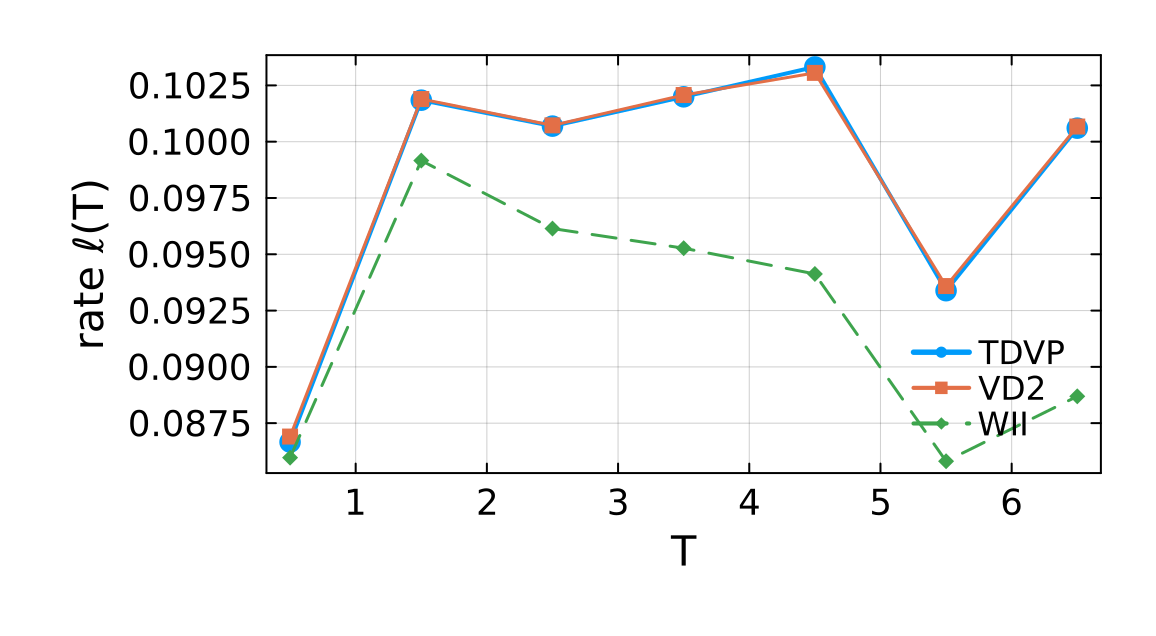

In [3]:
include("../scripts/analysis/rate_benchmark.jl")
rates_tdvp = tdvp_rate()          # reference, read from the TDVP cache at the same times
rates_vd2  = mpo_rate("VD2")
rates_wii  = mpo_rate("WII")

@printf("%-6s  %-10s  %-10s  %-10s  %-10s\n", "T", "TDVP", "VD2", "WII", "|VD2-TDVP|")
for (i, T) in enumerate(TARGET_TIMES)
    @printf("%-6.1f  %-10.5f  %-10.5f  %-10.5f  %-10.1e\n",
            T, rates_tdvp[i], rates_vd2[i], rates_wii[i], abs(rates_vd2[i] - rates_tdvp[i]))
end

pl = plot(xlabel="T", ylabel="rate ℓ(T)", legend=:bottomright, size=thesis_size(0.75; aspect=0.55))
plot!(pl, TARGET_TIMES, rates_tdvp, marker=:circle,  ms=6, msw=0, lw=2, label="TDVP")
plot!(pl, TARGET_TIMES, rates_vd2,  marker=:square,  ms=4, msw=0, lw=1.5, label="VD2")
plot!(pl, TARGET_TIMES, rates_wii,  marker=:diamond, ms=4, msw=0, lw=1.5, ls=:dash, label="WII")
pl

## The corrected transfer-matrix column

Here is the trap. The library builds $U(\delta t)$ on three sites and repeats the middle
tensor as the bulk column — exact for nearest-neighbour models. For our NNN model the middle
site of a three-site patch has no partner at distance two, so the extracted column silently
**loses a memory channel**: temporal physical dimension 7 where the true bulk tensor carries
13. Every production result at $p \neq 0$ computed on the 7-dimensional column had to be
discarded and rerun. The fix builds $U$ on five sites and takes the true middle tensor —
`column = :bulk5`, which the default still does *not* select, so every call passes it
explicitly.

In [4]:
# the trap, made visible: build one column each way at p=0.5 and compare the temporal
# site dimension (small live computation, a few seconds)
mpo_legacy, _ = build_alcaraz_tmpo(1.0; p=0.5, nbeta=4, column=:legacy3)
mpo_bulk, _   = build_alcaraz_tmpo(1.0; p=0.5, nbeta=4, column=:bulk5)
sitedim(m) = maximum(maximum(dim(i) for i in inds(t) if hastags(i, "Site")) for t in m)
@printf("temporal site dimension:  legacy %d   corrected %d\n",
        sitedim(mpo_legacy), sitedim(mpo_bulk))

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=458|"S=1/2,Site") <-> (dim=2|id=458|"S=1/2,Site")', normdiff = 0.276164202362773
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=520|"Link,l=1") <-> (dim=7|id=153|"Link,l=2"), normdiff = 1.3391131620216266
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=365|"S=1/2,Site") <-> (dim=2|id=365|"S=1/2,Site")', normdiff = 0.276164202362773
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=250|"Link,l=1") <-> (dim=7|id=948|"Link,l=2"), normdiff = 1.5642546233009473
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=350|"S=1/2,Site") <-> (dim=2|id=350|"S=1/2,Site")', normdiff = 0.276164202362773
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


temporal site dimension:  legacy 7   corrected 13


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=266|"Link,l=1") <-> (dim=7|id=449|"Link,l=2"), normdiff = 1.3391131620216266
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=935|"S=1/2,Site") <-> (dim=2|id=935|"S=1/2,Site")', normdiff = 0.276164202362773
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=113|"Link,l=1") <-> (dim=7|id=477|"Link,l=2"), normdiff = 1.5642546233009473
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


And the consequence is quantitative. Below, both columns are measured against the exact
answer: Krylov evolution of the physical echo on an open chain at $N = 12, 16, 20$, extrapolated
linearly in $1/N$. Nothing in that reference comes from a tensor network.

Read the table against its own control. At $p = 0$ the two columns are the *same* operator, so
their common distance from the exact rate — about $10^{-3}$ — is the error floor of the comparison
itself. At $p \neq 0$ the legacy column pulls several times further away than the corrected one,
and the gap widens with the coupling. The last row drifts for a separate reason: at $p = 0.5$ and
$T = 3$ the light cone $2vT \approx 31$ has outrun a chain of 20 sites, so the reference is the
part that is no longer converged there.

In [5]:
# Both columns against exact Krylov evolution. The echo rate of a finite chain still carries a
# boundary term that falls off as 1/N, so we extrapolate it away with a straight line first.
rates = load("../data/local/nb13_krylov_echo.jld2", "rates")
mu0   = load("../data/local/nb13_mu0.jld2", "mu0")

Ns = (12, 16, 20)
function exact_rate(p, T)
    intercept, slope = hcat(ones(3), [1 / N for N in Ns]) \ [rates[(p, N, T)] for N in Ns]
    return intercept
end
column_rate(p, col, T) = -log(abs(mu0[(p, col, T)]))

@printf("%-5s %-4s %-11s %-13s %-13s\n", "p", "T", "exact", "legacy3 dev", "bulk5 dev")
for p in (0.0, 0.1, 0.5), T in (1.0, 2.0, 3.0)
    ell  = exact_rate(p, T)
    dev3 = column_rate(p, :legacy3, T) - ell
    dev5 = p == 0.0 ? dev3 : column_rate(p, :bulk5, T) - ell   # same operator at p=0
    @printf("%-5.1f %-4.0f %-11.5f %+-13.5f %+-13.5f\n", p, T, ell, dev3, dev5)
end

p     T    exact       legacy3 dev   bulk5 dev    
0.0   1    -0.41400    +0.00101      +0.00101     


0.0   2    -0.40404    +0.00101      +0.00101     
0.0   3    -0.39925    -0.00103      -0.00103     
0.1   1    -0.45384    +0.00349      +0.00159     
0.1   2    -0.44765    +0.00492      +0.00175     
0.1   3    -0.44963    +0.00949      +0.00545     
0.5   1    -0.62781    +0.03173      +0.00475     
0.5   2    -0.63001    -0.00942      +0.00733     
0.5   3    -0.59935    -0.04702      -0.02330     


## The Ising benchmark: run the whole machine against exact answers

At $p = 0$ everything is known: $c = 1/2$, and the boundary spectrum of the strip depends on
the boundary state — the free boundary selects $x_1 = 1/2$, the fixed one $x_1 = 2$. So we run
the complete pipeline (evolve, rotate, contract, fit) and check both. One convention detail:
the built-in Ising model puts the field on $\sigma^z$, so *there* the free boundary is
$|\!\uparrow\rangle$ and the fixed one $|X+\rangle$ — exchanged relative to our model.

In [6]:
# c from the phase of the leading eigenvalue along the T ladder: fit
# phi(T) = A*T + B + C/T + D/T^3 and read c = 24*v*|C|/pi (v = 2 exactly for Ising).
x1d = load("../data/local/nb6_ising_x1.jld2", "done")
Ts = sort([T for (bc, T) in keys(x1d) if bc == "Up"])
phi = Float64[]
for T in Ts
    theta = x1d[("Up", T)].theta
    push!(phi, angle(-theta[argmax(abs.(theta))]))
end
for i in 2:length(phi)                       # unwrap the phase along the ladder
    d = phi[i] - phi[i-1]
    phi[i] = phi[i-1] + d - 2pi * round(d / (2pi))
end
A, B, C, D = hcat(Ts, ones(length(Ts)), 1 ./ Ts, 1 ./ Ts .^ 3) \ phi
@printf("Ising benchmark:  c = %.4f  (exact 1/2)   branch offset B = %.4f  (= -pi)\n",
        24 * 2.0 * abs(C) / pi, B)

Ising benchmark:  c = 0.4997  (exact 1/2)   branch offset B = -3.1416  (= -pi)


In [7]:
# x1 from the first phase gap, for both boundary states, at the longest cached time
for bc in ("Up", "X+")
    T = maximum(T for (b, T) in keys(x1d) if b == bc)
    e = x1d[(bc, T)]
    x = tower_dims(e.theta, T, 2.0; i0=argmax(abs.(e.theta)))
    @printf("boundary %-3s at T=%g:  x1 = %.3f   (CFT: %s)\n", bc, T, x[1], bc == "Up" ? "1/2" : "2")
end

boundary Up  at T=7:  x1 = 0.499   (CFT: 1/2)
boundary X+  at T=7:  x1 = 2.002   (CFT: 2)


Both exact answers reproduced: $c = 0.4997$, the branch offset lands on $-\pi$ as the
theory says it must, and the two boundary conditions return their own $x_1$. This is the
control every non-integrable measurement in notebooks 4 and 5 is compared against.

## How the block iteration converges — and when it stops improving

The transfer matrix is non-normal, so the block power method needs care: random complex seeds
(the structured seed converges to a subdominant sector), truncation of the block after each
application, a stopping rule. Under RTM truncation the change in the leading Ritz values
levels off *above* the tolerance and the run ends on a no-improvement rule; under RDM at the
same rung and seed it crosses the tolerance. The two return the same eigenvalue to
$1.9\times10^{-6}$: the floor is a property of the truncation, not of the physics.

rdm: converged, 74 iters, final change 8.34e-07, min 8.34e-07
rtm: stuck, 221 iters, final change 5.07e-06, min 2.45e-06


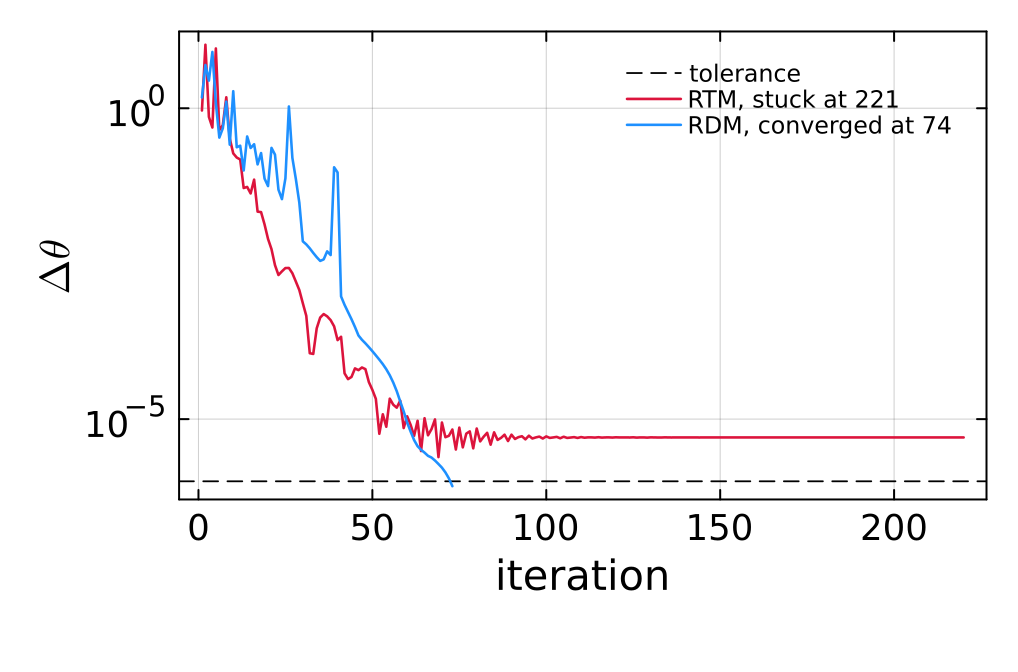

In [8]:
include("../scripts/figures/fig_conv.jl")
make_conv()

## Takeaways

- VD2 is the only genuinely second-order (and norm-preserving) kernel for this Hamiltonian —
  the norm test shows it in eight lines.
- The transfer-matrix column **must** be built from a five-site patch (`column = :bulk5`);
  the legacy extraction loses a memory channel and shifts $|\mu_0|$ from the third digit.
- The full pipeline reproduces every exact Ising answer.
- Every remaining numerical knob (seeds, cutoff, $\chi$, $\delta t$, warm starts, …) has its
  own measured control — those are collected in notebook 6.